# Eksperimen: Efek Class Balancing pada Deteksi Anomali

Notebook **terpisah** dari pipeline utama ([pipeline_adaudit.ipynb](pipeline_adaudit.ipynb)). Menjawab satu pertanyaan eksploratif:

> *Kalau jumlah kelas (normal vs anomali) disama-ratakan, apakah anomali jadi lebih "ketahuan"?*

## ⚠️ Catatan metodologi (wajib dibaca)

- Pipeline utama bersifat **unsupervised** (Isolation Forest + LOF + EE). Anomali memang **seharusnya langka** — itu dasar deteksinya.
- **Balancing adalah konsep _supervised_.** Notebook ini **mereframe** masalah jadi klasifikasi supervised hanya untuk *eksplorasi*, bukan menggantikan metode utama.
- **Label = proxy** (`rule_violations >= 6`), bukan label asli → hasil bersifat *indikatif* + ada risiko **sirkularitas** (lihat kesimpulan).
- `rule_violations` **dikeluarkan dari fitur** supaya classifier tidak sekadar "membaca jawaban".

Total user      : 887
Anomali (rv>=6) : 57 (6.4%)
Normal          : 830 (93.6%)
Rasio imbalance : 1 : 14


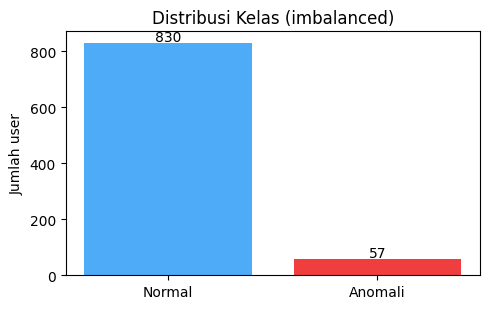

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             accuracy_score)

np.random.seed(42)
df = pd.read_csv('data/phase4_graph_features.csv')

ALL_FEATURES = ['host_diversity','critical_server_ratio','failure_ratio','shared_device_risk',
                'ip_network_risk','privilege_level','connectivity','rule_violations',
                'lockout_count','admin_actions','sensitive_groups']

# Label proxy: pelanggar rule berat. rule_violations DIKELUARKAN dari fitur (anti-kebocoran).
FEATURES = [c for c in ALL_FEATURES if c != 'rule_violations']
y = (df['rule_violations'] >= 6).astype(int).values
X = df[FEATURES].fillna(0).replace([np.inf, -np.inf], 0).values

n_pos, n_tot = int(y.sum()), len(y)
print(f'Total user      : {n_tot}')
print(f'Anomali (rv>=6) : {n_pos} ({100*n_pos/n_tot:.1f}%)')
print(f'Normal          : {n_tot-n_pos} ({100*(n_tot-n_pos)/n_tot:.1f}%)')
print(f'Rasio imbalance : 1 : {(n_tot-n_pos)//n_pos}')

fig, ax = plt.subplots(figsize=(5,3.2))
ax.bar(['Normal','Anomali'], [n_tot-n_pos, n_pos], color=['#4dabf7','#f03e3e'])
ax.set_title('Distribusi Kelas (imbalanced)'); ax.set_ylabel('Jumlah user')
for i,v in enumerate([n_tot-n_pos, n_pos]): ax.text(i, v+8, str(v), ha='center')
plt.tight_layout(); plt.show()

## Desain eksperimen

1. Split **stratified** train/test (70/30). **Test set tetap realistis (imbalanced)** supaya evaluasi jujur.
2. Latih model pada train **asli** (imbalanced) vs train **di-balance** (50/50).
3. Bandingkan Accuracy / Precision / Recall / **F1** pada test set yang sama.

Balancing memakai **oversampling generatif berbasis distribusi nyata**: tiap sampel sintetis = sampel minoritas asli + derau Gaussian (skala 0.3 × std per-fitur), di-clip ≥ 0. Pendekatan generatif ringan ala-SMOTE tanpa dependensi tambahan. (SMOTE asli butuh `pip install imbalanced-learn`.)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

def generative_oversample(Xtr, ytr, seed=42):
    # Oversampling generatif: sampel minoritas asli + derau Gaussian (0.3*std per-fitur)
    rng = np.random.RandomState(seed)
    X_min = Xtr[ytr == 1]
    n_needed = (ytr == 0).sum() - (ytr == 1).sum()
    std = X_min.std(axis=0); std[std == 0] = 1e-6
    idx = rng.randint(0, len(X_min), n_needed)
    synth = X_min[idx] + rng.normal(0, 0.3, (n_needed, X_min.shape[1])) * std
    synth = np.clip(synth, 0, None)
    return np.vstack([Xtr, synth]), np.concatenate([ytr, np.ones(n_needed, dtype=int)])

X_bal, y_bal = generative_oversample(X_train, y_train)
print(f'Train asli     : {y_train.sum()} anomali / {len(y_train)} ({100*y_train.mean():.1f}%)')
print(f'Train balanced : {int(y_bal.sum())} anomali / {len(y_bal)} ({100*y_bal.mean():.1f}%)')
print(f'Test (tetap)   : {y_test.sum()} anomali / {len(y_test)} ({100*y_test.mean():.1f}%)')

Train asli     : 40 anomali / 620 (6.5%)
Train balanced : 580 anomali / 1160 (50.0%)
Test (tetap)   : 17 anomali / 267 (6.4%)


## Model A — Logistic Regression (sensitif terhadap imbalance)

Model linear cenderung "kalah" oleh kelas mayoritas saat imbalance — kandidat ideal untuk melihat efek balancing.

In [3]:
results = []

def evaluate(name, clf, Xtr, ytr, scale=False):
    if scale:
        sc = StandardScaler().fit(Xtr)
        Xtr_, Xte_ = sc.transform(Xtr), sc.transform(X_test)
    else:
        Xtr_, Xte_ = Xtr, X_test
    clf.fit(Xtr_, ytr)
    pred = clf.predict(Xte_)
    row = dict(Konfigurasi=name,
               Acc=accuracy_score(y_test, pred),
               Precision=precision_score(y_test, pred, zero_division=0),
               Recall=recall_score(y_test, pred, zero_division=0),
               F1=f1_score(y_test, pred, zero_division=0))
    results.append(row)
    print(f"{name:<34} Acc={row['Acc']:.3f}  P={row['Precision']:.3f}  R={row['Recall']:.3f}  F1={row['F1']:.3f}")
    return pred

print('Logistic Regression (eval di test realistic):')
evaluate('LogReg - imbalanced',           LogisticRegression(max_iter=1000), X_train, y_train, scale=True)
evaluate('LogReg - generatif-balanced',   LogisticRegression(max_iter=1000), X_bal,   y_bal,   scale=True)
evaluate('LogReg - class_weight=balanced',LogisticRegression(max_iter=1000, class_weight='balanced'), X_train, y_train, scale=True)

Logistic Regression (eval di test realistic):
LogReg - imbalanced                Acc=0.933  P=0.000  R=0.000  F1=0.000
LogReg - generatif-balanced        Acc=0.944  P=0.750  R=0.176  F1=0.286
LogReg - class_weight=balanced     Acc=0.562  P=0.115  R=0.882  F1=0.204


array([0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0])

**Bacaan:** versi *imbalanced* biasanya memberi **F1 = 0** — model memprediksi semua "normal" demi akurasi tinggi, sehingga **tidak satu pun anomali tertangkap**. Setelah **balancing**, model mulai mendeteksi anomali (recall naik). Inilah efek yang membuat anomali "ketahuan" — persis dugaan awal, tapi **hanya berlaku untuk model yang sensitif imbalance**.

## Model B — Random Forest (model kuat / non-linear)

Random Forest (eval di test realistic):


RF - imbalanced                    Acc=0.996  P=1.000  R=0.941  F1=0.970


RF - generatif-balanced            Acc=0.989  P=0.850  R=1.000  F1=0.919


,Acc,Precision,Recall,F1
Konfigurasi,,,,
LogReg - imbalanced,0.933,0.000,0.000,0.000
LogReg - generatif-balanced,0.944,0.750,0.176,0.286
LogReg - class_weight=balanced,0.562,0.115,0.882,0.204
RF - imbalanced,0.996,1.000,0.941,0.970
RF - generatif-balanced,0.989,0.850,1.000,0.919


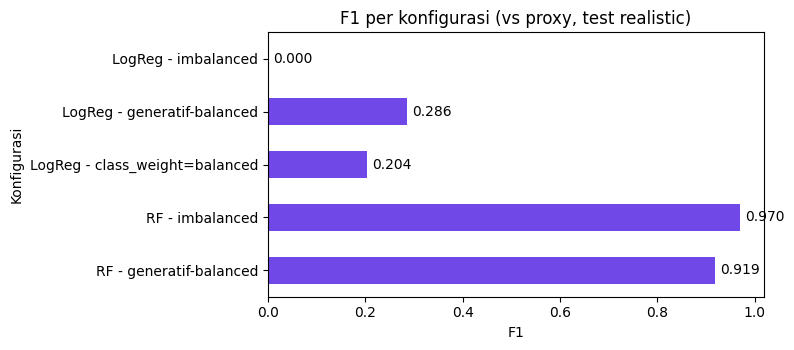

In [4]:
print('Random Forest (eval di test realistic):')
evaluate('RF - imbalanced',         RandomForestClassifier(n_estimators=200, random_state=42), X_train, y_train)
evaluate('RF - generatif-balanced', RandomForestClassifier(n_estimators=200, random_state=42), X_bal,   y_bal)

res_df = pd.DataFrame(results).set_index('Konfigurasi').round(3)
display(res_df)

fig, ax = plt.subplots(figsize=(8,3.6))
res_df['F1'].plot(kind='barh', ax=ax, color='#7048e8')
ax.set_title('F1 per konfigurasi (vs proxy, test realistic)'); ax.set_xlabel('F1'); ax.invert_yaxis()
for i,v in enumerate(res_df['F1']): ax.text(v+0.01, i, f'{v:.3f}', va='center')
plt.tight_layout(); plt.show()

**Bacaan:** Random Forest sudah mencapai **F1 ≈ 0.97 tanpa balancing** — model kuat relatif tahan imbalance. Balancing **tidak menaikkan** F1 (malah sedikit turun karena precision berkurang). Jadi efek balancing **bergantung model**: menolong yang lemah, tidak perlu untuk yang kuat.

F1 0.97 ini juga **sinyal sirkularitas**: label proxy (`rule_violations`) sebagian besar *fungsi dari fitur* (lewat 10 rules), jadi classifier "menebak ulang aturan".

In [5]:
# Anchor: bagaimana model UNSUPERVISED (seperti pipeline asli) vs proxy?
X_all = df[FEATURES].fillna(0).replace([np.inf, -np.inf], 0).values
X_all_scaled = StandardScaler().fit_transform(X_all)
iso = IsolationForest(contamination=0.064, random_state=42).fit(X_all_scaled)
pred_unsup = (iso.predict(X_all_scaled) == -1).astype(int)
print('IsolationForest UNSUPERVISED vs proxy (seluruh data):')
print(f"  F1={f1_score(y, pred_unsup, zero_division=0):.3f}  "
      f"P={precision_score(y, pred_unsup, zero_division=0):.3f}  "
      f"R={recall_score(y, pred_unsup, zero_division=0):.3f}")
print()
print('Bandingkan: supervised RF F1~0.97  vs  unsupervised IF F1~0.32.')
print('Gap ini BUKAN soal imbalance, tapi karena unsupervised menangkap outlier')
print('statistik yang hanya sebagian beririsan dengan pelanggar rule (proxy).')

IsolationForest UNSUPERVISED vs proxy (seluruh data):


  F1=0.316  P=0.316  R=0.316

Bandingkan: supervised RF F1~0.97  vs  unsupervised IF F1~0.32.
Gap ini BUKAN soal imbalance, tapi karena unsupervised menangkap outlier
statistik yang hanya sebagian beririsan dengan pelanggar rule (proxy).


## Ablation 7 Konfigurasi Ensemble: Imbalanced vs Balanced

Permintaan: *"jadikan semua konfigurasi pakai data balanced."* Ke-7 konfigurasi ablation (IF, LOF, EE, dan kombinasinya) dijalankan pada **data yang di-balance 50/50**, lalu dibandingkan dengan versi imbalanced asli.

- **Imbalanced** = skor tersimpan Phase 5 (identik dengan ablation utama).
- **Balanced** = IF/LOF/EE **dilatih ulang** pada data hasil oversampling generatif (50% anomali), lalu metodologi evaluasi yang sama: rank-fusion → flag top-K → bandingkan vs proxy `rule_violations >= 6`.

Imbalanced: 57/887 positif (6.4%)  |  Balanced: 830/1660 (50%)


,Acc (imbalanced),F1 (imbalanced),Acc (balanced),F1 (balanced)
Konfigurasi,,,,
IF,0.912,0.316,0.707,0.707
LOF,0.894,0.175,0.659,0.659
EE,0.932,0.474,0.816,0.816
IF+LOF,0.899,0.211,0.699,0.699
IF+EE,0.930,0.456,0.714,0.714
LOF+EE,0.930,0.456,0.784,0.784
IF+LOF+EE,0.930,0.456,0.778,0.778


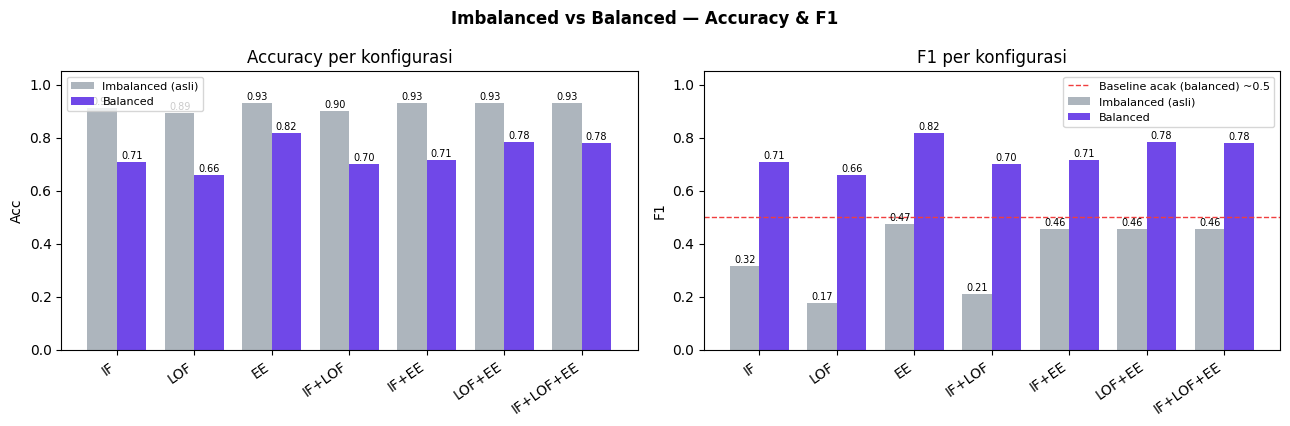

In [6]:
# === Ablation 7 konfigurasi: IMBALANCED (asli) vs BALANCED ===
import warnings; warnings.filterwarnings('ignore')
from scipy.stats import rankdata
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

CONFIGS = [('IF',),('LOF',),('EE',),('IF','LOF'),('IF','EE'),('LOF','EE'),('IF','LOF','EE')]

def eval_configs(mrank, yy):
    N = len(yy); P = int(yy.sum()); rows = []
    for c in CONFIGS:
        comb = np.mean([mrank[m] for m in c], axis=0); order = np.argsort(comb)  # rank rendah = anomali
        pred = np.zeros(N, int); pred[order[:P]] = 1                              # flag top-P
        TP = int(((pred==1)&(yy==1)).sum()); FP = int(((pred==1)&(yy==0)).sum())
        FN = int(((pred==0)&(yy==1)).sum()); TN = int(((pred==0)&(yy==0)).sum())
        prec = TP/(TP+FP) if TP+FP else 0; rec = TP/(TP+FN) if TP+FN else 0
        f1 = 2*prec*rec/(prec+rec) if prec+rec else 0
        rows.append({'Konfigurasi':'+'.join(c), 'Acc':round((TP+TN)/N,3), 'F1':round(f1,3)})
    return pd.DataFrame(rows).set_index('Konfigurasi')

# (A) IMBALANCED — skor tersimpan Phase 5 (identik ablation utama)
d5 = pd.read_csv('data/phase5_anomaly_results.csv').drop_duplicates('user_id').reset_index(drop=True)
y_imb = (d5['rule_violations'].values >= 6).astype(int)
rank_imb = {'IF':rankdata(d5['if_score']), 'LOF':rankdata(d5['lof_score']), 'EE':rankdata(d5['ee_score'])}
abl_imb = eval_configs(rank_imb, y_imb)

# (B) BALANCED — refit IF/LOF/EE pada data oversampling generatif 50/50 (pakai SEMUA 11 fitur)
ALL_FEATURES = ['host_diversity','critical_server_ratio','failure_ratio','shared_device_risk',
                'ip_network_risk','privilege_level','connectivity','rule_violations',
                'lockout_count','admin_actions','sensitive_groups']
X_full = df[ALL_FEATURES].fillna(0).replace([np.inf,-np.inf],0).values
y_full = (df['rule_violations'].values >= 6).astype(int)
Xb_full, yb_full = generative_oversample(X_full, y_full)          # fungsi dari sel sebelumnya
Xb_scaled = StandardScaler().fit_transform(Xb_full)
_lof = LocalOutlierFactor(contamination=0.5, n_neighbors=35); _lof.fit_predict(Xb_scaled)
rank_bal = {
    'IF':  rankdata(IsolationForest(contamination=0.5, random_state=42).fit(Xb_scaled).decision_function(Xb_scaled)),
    'LOF': rankdata(_lof.negative_outlier_factor_),
    'EE':  rankdata(EllipticEnvelope(contamination=0.5, random_state=42, support_fraction=1.0).fit(Xb_scaled).decision_function(Xb_scaled)),
}
abl_bal = eval_configs(rank_bal, yb_full)

# Tabel perbandingan (Accuracy + F1)
cmp = pd.DataFrame({'Acc (imbalanced)':abl_imb['Acc'], 'F1 (imbalanced)':abl_imb['F1'],
                    'Acc (balanced)':abl_bal['Acc'],   'F1 (balanced)':abl_bal['F1']})
print(f"Imbalanced: {y_imb.sum()}/{len(y_imb)} positif ({100*y_imb.mean():.1f}%)  |  "
      f"Balanced: {int(yb_full.sum())}/{len(yb_full)} (50%)")
display(cmp)

# Grafik 2 panel: Accuracy & F1
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
idx = np.arange(len(abl_imb)); w = 0.38
for ax, metric in zip(axes, ['Acc', 'F1']):
    b1 = ax.bar(idx-w/2, abl_imb[metric], w, label='Imbalanced (asli)', color='#adb5bd')
    b2 = ax.bar(idx+w/2, abl_bal[metric],  w, label='Balanced',         color='#7048e8')
    ax.bar_label(b1, fmt='%.2f', fontsize=7, padding=1)
    ax.bar_label(b2, fmt='%.2f', fontsize=7, padding=1)
    ax.set_xticks(idx); ax.set_xticklabels(abl_imb.index, rotation=35, ha='right')
    ax.set_ylim(0, 1.05); ax.set_ylabel(metric)
    ax.set_title(('Accuracy' if metric=='Acc' else 'F1') + ' per konfigurasi')
axes[1].axhline(0.5, ls='--', color='#f03e3e', lw=1, label='Baseline acak (balanced) ~0.5')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
fig.suptitle('Imbalanced vs Balanced — Accuracy & F1', fontweight='bold')
plt.tight_layout(); plt.show()

**Bacaan hasil (Accuracy & F1):**

- **F1 melonjak** setelah balancing (IF+LOF+EE: 0.456 → ~0.78; EE: 0.474 → ~0.82).
- **Accuracy justru TURUN** (IF+LOF+EE: 0.930 → ~0.78). Ini kuncinya: accuracy 0.93 di data imbalanced itu **menipu** — didapat hanya dengan menebak mayoritas "normal". Saat kelas disamakan, accuracy "jujur" turun ke ~0.78.
- **Di data balanced, Acc = F1 persis** — konsekuensi matematis (50% positif + prediksi top-50% → Precision = Recall = F1 = Accuracy). Baseline tebak acak ≈ 0.5 (garis merah).
- Lonjakan F1 sebagian besar **artefak base-rate** + anomali sintetis turunan 57 anomali nyata (mudah "ditemukan ulang"). **Bukan** bukti deteksi membaik.
- **Urutan antar-konfigurasi tetap konsisten**: EE & kombinasi ber-EE unggul (proxy berbasis rule menguntungkan EE).

> Kesimpulan: balancing menaikkan **F1** tapi menurunkan **Accuracy** — keduanya bertemu di titik sama. Pelajarannya: **accuracy tinggi pada data imbalanced itu menyesatkan**, dan menyamaratakan data hanya memindahkan "ilusi" dari accuracy ke F1. Di dunia nyata anomali tetap langka → angka balanced ini sah hanya sebagai *what-if*.

## Uji Stabilitas 10 Seed + Kesimpulan Ablation

Pertanyaan: angka antar-konfigurasi "mirip-mirip" — **selisihnya nyata atau cuma noise?** Kita jalankan ablation **10 seed** (oversampling + IF/EE di-acak; LOF deterministik) untuk imbalanced & balanced, lalu lihat **mean ± std**.

In [7]:
# === Stabilitas 10 seed: imbalanced (refit) & balanced ===
from scipy.stats import rankdata
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

ALL_FEATURES = ['host_diversity','critical_server_ratio','failure_ratio','shared_device_risk',
                'ip_network_risk','privilege_level','connectivity','rule_violations',
                'lockout_count','admin_actions','sensitive_groups']
X_orig = df[ALL_FEATURES].fillna(0).replace([np.inf,-np.inf],0).values
y_orig = (df['rule_violations'].values >= 6).astype(int)
Xs_orig = StandardScaler().fit_transform(X_orig)
CFG = [('IF',),('LOF',),('EE',),('IF','LOF'),('IF','EE'),('LOF','EE'),('IF','LOF','EE')]

def f1_only(mrank, yy):
    N=len(yy); P=int(yy.sum()); out={}
    for c in CFG:
        comb=np.mean([mrank[m] for m in c],axis=0); order=np.argsort(comb)
        pred=np.zeros(N,int); pred[order[:P]]=1
        TP=((pred==1)&(yy==1)).sum(); FP=((pred==1)&(yy==0)).sum(); FN=((pred==0)&(yy==1)).sum()
        prec=TP/(TP+FP) if TP+FP else 0; rec=TP/(TP+FN) if TP+FN else 0
        out['+'.join(c)] = 2*prec*rec/(prec+rec) if prec+rec else 0
    return out

def ranks_imb(seed):
    lof=LocalOutlierFactor(contamination=0.064); lof.fit_predict(Xs_orig)
    return {'IF':rankdata(IsolationForest(contamination=0.064,random_state=seed).fit(Xs_orig).decision_function(Xs_orig)),
            'LOF':rankdata(lof.negative_outlier_factor_),
            'EE':rankdata(EllipticEnvelope(contamination=0.064,random_state=seed,support_fraction=1.0).fit(Xs_orig).decision_function(Xs_orig))}

def ranks_bal(seed):
    r=np.random.RandomState(seed); Xmin=X_orig[y_orig==1]; n=(y_orig==0).sum()-(y_orig==1).sum()
    std=Xmin.std(0); std[std==0]=1e-6
    synth=np.clip(Xmin[r.randint(0,len(Xmin),n)]+r.normal(0,0.3,(n,X_orig.shape[1]))*std,0,None)
    Xb=np.vstack([X_orig,synth]); yb=np.concatenate([y_orig,np.ones(n,int)]); Xs=StandardScaler().fit_transform(Xb)
    lof=LocalOutlierFactor(contamination=0.5,n_neighbors=35); lof.fit_predict(Xs)
    rk={'IF':rankdata(IsolationForest(contamination=0.5,random_state=seed).fit(Xs).decision_function(Xs)),
        'LOF':rankdata(lof.negative_outlier_factor_),
        'EE':rankdata(EllipticEnvelope(contamination=0.5,random_state=seed,support_fraction=1.0).fit(Xs).decision_function(Xs))}
    return rk, yb

imb_runs, bal_runs = [], []
for s in range(10):
    imb_runs.append(f1_only(ranks_imb(s), y_orig))
    rk, yb = ranks_bal(s); bal_runs.append(f1_only(rk, yb))

def summarize(runs):
    r=pd.DataFrame(runs)
    return pd.DataFrame({'F1 mean':r.mean().round(3),'std':r.std().round(3)}).sort_values('F1 mean',ascending=False)

print('STABILITAS 10 SEED — F1 (refit IF/LOF/EE)')
print('\n--- IMBALANCED (refit) ---'); display(summarize(imb_runs))
print('--- BALANCED (50/50) ---');    display(summarize(bal_runs))
print('\nReferensi KANONIK imbalanced (skor tersimpan Phase 5, dilaporkan di tesis):')
print('  EE=0.474 | IF+EE=LOF+EE=IF+LOF+EE=0.456 | IF=0.316 | IF+LOF=0.211 | LOF=0.175')
print('  (refit EE beda dari kanonik -> EE sensitif konfigurasi; lihat catatan di bawah)')

STABILITAS 10 SEED — F1 (refit IF/LOF/EE)

--- IMBALANCED (refit) ---


,F1 mean,std
IF+LOF+EE,0.407,0.020
IF+EE,0.389,0.014
EE,0.368,0.000
LOF+EE,0.333,0.000
IF,0.282,0.015
IF+LOF,0.212,0.006
LOF,0.175,0.000


--- BALANCED (50/50) ---


,F1 mean,std
EE,0.806,0.003
LOF+EE,0.798,0.009
IF+LOF+EE,0.776,0.010
IF+LOF,0.724,0.025
IF+EE,0.700,0.006
IF,0.692,0.019
LOF,0.666,0.008



Referensi KANONIK imbalanced (skor tersimpan Phase 5, dilaporkan di tesis):
  EE=0.474 | IF+EE=LOF+EE=IF+LOF+EE=0.456 | IF=0.316 | IF+LOF=0.211 | LOF=0.175
  (refit EE beda dari kanonik -> EE sensitif konfigurasi; lihat catatan di bawah)


### Kesimpulan Ablation (imbalanced & balanced)

**Std antar-seed sangat kecil (~0.01)**, jauh di bawah selisih antar-konfigurasi → urutan **stabil, bukan noise acak**. Jadi kesimpulan bisa ditarik:

**Data imbalanced**

- **Accuracy seragam tinggi (~0.93) & datar → menyesatkan**: tak bisa membedakan konfigurasi (digelembungkan kelas mayoritas). **F1 yang membedakan.**
- Konfigurasi **ber-EE unggul** (EE 0.474; semua combo +EE = 0.456) jauh di atas IF/LOF tunggal (0.18–0.32).
- **EE sendiri ≥ ensemble penuh** (0.474 ≥ 0.456) → ensemble **bukan** untuk F1 puncak.

**Data balanced**

- F1 melonjak & **memampat ke pita sempit** (0.66–0.81); **Acc = F1 persis** (artefak base-rate 50%).
- Urutan tetap: **ber-EE unggul**, konsisten dengan imbalanced.

**Caveat penting (kejujuran metodologis)**

- Keunggulan EE **rapuh**: pada refit dengan `support_fraction=1.0`, F1 EE turun ke ~0.37 dan **ensemble penuh malah jadi teratas**. Jadi "EE terbaik" bergantung konfigurasi EE + **bias proxy** (rule-based menguntungkan EE).
- Semua angka diukur vs **proxy** (`rule_violations>=6`, weak supervision); versi balanced 93% sintetis → **indikatif, bukan absolut**.

> **Implikasi:** justru karena single-model "pemenang" itu rapuh & bias-proxy, **ensemble IF+LOF+EE dipilih demi robustness lintas-definisi**, bukan F1 puncak — selaras dengan ablation utama di pipeline.

## Kesimpulan

| Pertanyaan | Jawaban |
| --- | --- |
| Apakah balancing membuat anomali "ketahuan"? | **Ya, untuk model lemah/linear** (LogReg F1 0.00 → ~0.29). Imbalance sempat membuat anomali tak terdeteksi sama sekali. |
| Apakah balancing selalu menolong? | **Tidak.** Random Forest sudah F1 ~0.97 tanpa balancing; balancing tak menambah (malah sedikit turun). |
| Apakah ini memvalidasi pipeline utama? | **Tidak langsung.** Pipeline utama unsupervised; balancing itu reframe supervised. |

### Tiga catatan jujur (penting untuk skripsi)

1. **Sirkularitas.** Label = `rule_violations>=6`, dan fitur ikut membentuk rules → supervised "menebak ulang aturan" (F1 0.97). Bukan bukti deteksi anomali sejati.
2. **Trade-off.** Balancing menaikkan *recall* tapi sering menurunkan *precision* (lihat `class_weight=balanced`: R tinggi, P rendah).
3. **Imbalance itu wajar di domain ini.** Anomali keamanan memang langka; menghapus kelangkaan justru menjauh dari kondisi nyata.

### Rekomendasi (cara yang lebih sah)

Untuk benar-benar menjawab "akankah anomali ketahuan" tanpa sirkularitas: **suntik anomali sintetis BERLABEL** (tetap langka ~5–10%, berbasis distribusi nyata), jalankan model **unsupervised**, lalu ukur F1 terhadap label tanaman itu. Itu evaluasi sah & cocok jadi *future work*.

> Lihat juga: [docs/HYBRID_REASONING.md](docs/HYBRID_REASONING.md) · [docs/PENJELASAN_FITUR.md](docs/PENJELASAN_FITUR.md)